In [1]:
from pathlib import Path
import pandas as pd

# Go up one level from /notebooks to the project root
PROJECT_ROOT = Path().resolve().parent

# Build the path to the data folder
file_path = PROJECT_ROOT / "data" / "Oil&GasWells.csv"

df = pd.read_csv(file_path)

df.info()
df.describe(include='all').T
df.isna().mean().sort_values(ascending=False).head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24174 entries, 0 to 24173
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   OBJ_ID                        24174 non-null  int64  
 1   Permit number - API           24174 non-null  float64
 2   Well Type                     24016 non-null  object 
 3   Well Status                   24174 non-null  object 
 4   Well_GIS_Status               21445 non-null  object 
 5   County                        24174 non-null  object 
 6   Township                      24161 non-null  object 
 7   Company                       24174 non-null  object 
 8   Well_OP_Address               24157 non-null  object 
 9   Well_CompanyPHONE             24039 non-null  object 
 10  Elevation                     23858 non-null  float64
 11  DU_ACRES                      13894 non-null  float64
 12  Well_WH_LAT                   23957 non-null  float64
 13  W

OWPS Description                1.000000
Toe Longitude                   0.994871
Toe Latitude                    0.994871
Heel Longitude                  0.981013
Heel Latitude                   0.981013
Well_BH_LONG                    0.980268
Well_BH_LAT                     0.979193
Well_CompanyADDR2               0.979151
SecondProdFormation             0.965169
Orphan Well Program Status      0.964052
Well_ProposedFormations         0.867089
GeoPhysLogs                     0.709192
Well_Date_Plugged               0.660255
Last_Nonzero_Production_Year    0.654463
Last_Production_Quarter         0.639282
Last_Inspection_Date            0.606106
Well_IP_OIL                     0.444982
Producing Formation             0.437578
Well_Date_Approved              0.430752
Well_IP_GAS                     0.429925
dtype: float64

The dataset contains 24,174 wells with 58 attributes, spanning well characteristics, spatial coordinates, production metrics, operator information, and inspection history.
The dataset shows a wide range of completeness:

Fully or near-fully populated fields
County, Well Status, Well Latitude/Longitude, OBJ_ID, shale indicators
(These provide a strong source for geospatial and categorical analysis.)

Moderately populated fields (~50–80% completeness)
Well Date Complete, Total Depth, IP Oil/Gas, Producing Formation
(Usable for modeling but require NA handling.)

Sparse or highly incomplete fields (>95% missing)
Toe/Heel coordinates (likely only for horizontal wells)
Well_BH_LAT/LONG (bottom-hole often missing)
SecondProdFormation, Well_ProposedFormations
Orphan Well Program Status
(These should might want to be removed.)

Completely empty field
OWPS Description is 100% null, drop from analysis.

High Missingness Features (Top 10)
Feature	% Missing	Interpretation
OWPS Description	100%	Drop
Toe Latitude / Longitude	~99%	
Heel Longitude / Latitude	~98%
Well_BH_LAT/LONG	~98%
SecondProdFormation	96%	
Orphan Well Program Status	96%	
Proposed Formations	86%	
GeoPhysLogs	71%	

Conclusion:
For the Stonebridge-style modeling, focus on latitude/longitude, depth, IP metrics, dates, formations, county, operator, and inspection dates, and avoid highly sparse fields.

In [2]:
df[['Well_WH_LAT','Well_WH_LONG','Well Latitude','Well Longitude']].describe()


,Well_WH_LAT,Well_WH_LONG,Well Latitude,Well Longitude
count,23957.000000,23952.000000,24174.000000,24174.000000
mean,40.307916,-81.944793,40.318045,-81.948048
std,0.903855,0.851189,0.691150,0.855444
min,0.000000,-84.813767,38.427535,-84.813722
25%,39.702086,-82.267491,39.702445,-82.268468
50%,40.344393,-81.901778,40.346964,-81.904109
75%,40.878499,-81.308290,40.880879,-81.308120
max,41.956880,-80.520469,41.956935,-80.520259


In [3]:
df[(df['Well Latitude'] < 38) | (df['Well Latitude'] > 42)]
df[(df['Well Longitude'] > -80) | (df['Well Longitude'] < -85)]


,OBJ_ID,Permit number - API,Well Type,Well Status,Well_GIS_Status,County,Township,Company,Well_OP_Address,Well_CompanyPHONE,...,Toe Latitude,Heel Longitude,Heel Latitude,OWPS Description,Last_Inspection_Date,Last_Nonzero_Production_Year,Last_Production_Quarter,Orphan Well Program Status,x,y


In [4]:
df['lat_delta'] = abs(df['Well Latitude'] - df['Bottom Hole Latitude'])
df['long_delta'] = abs(df['Well Longitude'] - df['Bottom Hole Longitude'])

df[['lat_delta','long_delta']].describe()


,lat_delta,long_delta
count,21303.000000,21303.000000
mean,39.239837,79.799715
std,6.533056,13.244658
min,0.000000,0.000000
25%,39.658689,81.296452
50%,40.330124,81.926424
75%,40.865628,82.276765
max,41.956935,84.803084


Here’s what we found when looking at the different location fields in the dataset:
1. The main well coordinates look good
The fields Well Latitude and Well Longitude have no missing values.
Their ranges (lat ~38.4–42.0, long ~–84.8 to –80.5) match what we’d expect for wells located in Ohio.
These should be our primary fields for mapping and spatial analysis.

2. The wellhead coordinates (Well_WH_LAT / Well_WH_LONG) mostly match the main coordinates
~99% complete
Values fall in the same Ohio range
A few wells have zeros for latitude
These fields are usable, but the main latitude/longitude fields are cleaner.

3. Bottom-hole, toe, and heel coordinates are mostly missing
Bottom-hole lat/long only exist for ~21K wells (out of 24K)
Toe and heel coordinates exist for <1% of wells
These fields can’t reliably be used to identify horizontal wells or measure lateral length.

4. The “delta” calculations between surface and bottom-hole coordinates are not meaningful yet
We calculated differences between wellhead and bottom-hole coordinates (lat_delta / long_delta).
The deltas are way too large (mean of ~39° latitude difference), which isn’t physically possible.

This means:
some wells have placeholder or incorrect bottom-hole coordinates
or the fields were entered using a different coordinate system
or missing values were coded as zeros/80s/etc.

So we shouldn’t use any of the delta calculations until we fix the coordinate inconsistencies.

In [5]:
df['Well Type'].value_counts(dropna=False)



Well Type
Oil and gas                       3566
Dry hole                          2884
Oil                               2719
Gas                               2508
Plugged oil                       2434
Expired permit                    2350
Plugged oil and gas               2325
Plugged gas                       1928
Unknown status                    1030
Gas with oil show                  568
Gas storage                        330
Dry hole with gas show             262
Plugged gas with oil show          245
Dry hole with oil show             168
NaN                                158
Dry hole with oil and gas show     148
Plugged oil with gas show          141
Oil with gas show                  113
Gas show                            52
Injection                           43
Gas and oil show                    40
Plugged injection                   40
Permitted location                  29
Oil show                            26
Lost hole                           22
Plugged with ga

In [6]:
df['Well Status'].value_counts(dropna=False)


Well Status
Plugged and Abandoned              6822
Producing                          6066
Final Restoration                  3897
Permit Expired                     2729
Unknown status                     2641
Well Drilled                       1066
Storage Well                        331
Orphan Well - Ready                 230
Field Inspected, Well Not Found     203
Orphan Well - Pending                57
Cancelled                            56
Active Injection                     50
Well Permitted                       18
Drilling                              8
Name: count, dtype: int64

In [7]:
df['Producing Formation'].value_counts(dropna=False).head(20)


Producing Formation
NaN                         10578
CLINTON SAND                 7365
BEREA SANDSTONE              2462
CLINTON GROUP                 644
TRENTON LIMESTONE             342
OHIO SHALE                    322
POINT PLEASANT FORMATION      275
TREMPEALEAU FORMATION         166
1ST COW RUN SANDSTONE         145
ROSE RUN SANDSTONE            134
KEENER SAND                   125
ORISKANY SANDSTONE            121
BIG INJUN SAND                104
2ND BEREA SAND                 99
MAXTON SAND                    95
MEDINA SAND                    93
PENNSYLVANIAN                  91
GORDON SAND                    86
LOCKPORT DOLOMITE              70
UTICA SHALE                    57
Name: count, dtype: int64

In [8]:
df[['Utica_Shale','Marcellus_Shale']].describe()

,Utica_Shale,Marcellus_Shale
count,24174.000000,24174.000000
mean,0.017126,0.000496
std,0.129743,0.022275
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


We examined the distributions of Well Type, Well Status, and Producing Formation to understand the overall structure of the well inventory and the geologic targets driving activity across the dataset. The Well Type breakdown shows a diverse mix of producing wells, dry holes, plugged wells, and wells with oil/gas shows, giving us an early sense of drilling outcomes and operational behavior. The Well Status distribution highlights that the largest groups are Producing and Plugged and Abandoned, which helps distinguish active infrastructure from legacy wells that may have different operational or environmental considerations. The Producing Formation summary identifies the Clinton Sand, Berea Sandstone, and related Clinton Group intervals as the dominant reservoirs in the dataset, providing context for where most historical and current production activity is concentrated. Finally, we looked at the Utica_Shale and Marcellus_Shale indicators because these two formations represent major unconventional shale targets in the region; tracking them separately helps us identify horizontal or deeper wells, which often differ in drilling practices, production behavior, and regulatory characteristics.

In [9]:
date_cols = ['Well_Date_Approved','Well_Date_Complete','Well_Date_Plugged']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df[date_cols].describe()


,Well_Date_Approved,Well_Date_Complete,Well_Date_Plugged
count,13761,21404,8205
mean,1985-11-15 16:58:51.850882880,1946-10-21 15:39:36.901513728,1971-04-22 08:57:48.811700184
min,1900-09-01 15:37:00,1900-01-01 00:00:00,1900-08-01 00:00:00
25%,1977-08-31 16:23:00,1900-01-02 00:00:00,1950-03-07 00:00:00
50%,1984-06-13 00:00:00,1952-12-05 00:00:00,1971-06-28 00:00:00
75%,1996-09-13 00:00:00,1981-03-26 00:00:00,1993-11-12 00:00:00
max,2025-11-06 15:40:00,2025-09-14 00:00:00,2025-10-29 00:00:00


In [10]:
pd.set_option('display.max_rows', None)

df['Well_Date_Approved'] = pd.to_datetime(df['Well_Date_Approved'], errors='coerce')
df['Well_Date_Complete'] = pd.to_datetime(df['Well_Date_Complete'], errors='coerce')
df['Well_Date_Plugged'] = pd.to_datetime(df['Well_Date_Plugged'], errors='coerce')

approved = df.groupby(df['Well_Date_Approved'].dt.year).size()
completed = df.groupby(df['Well_Date_Complete'].dt.year).size()
plugged   = df.groupby(df['Well_Date_Plugged'].dt.year).size()

combined = pd.concat([approved, completed, plugged], axis=1)
combined.columns = ['Approved', 'Completed', 'Plugged']

combined = combined.fillna(0).astype(int)

combined = combined.sort_index()
combined


,Approved,Completed,Plugged
1900.0,1,6519,1
1901.0,1,28,2
1902.0,0,32,2
1903.0,1,33,6
1904.0,0,28,8
1905.0,0,37,4
1906.0,0,40,2
1907.0,0,36,11
1908.0,1,29,12
1909.0,1,39,13


The yearly trends show a long historical record of well activity, with data extending back to the early 1900s. Completion counts are extremely high from 1900–1950, which reflects the early conventional drilling boom in Ohio and the fact that many of these wells were drilled before modern permitting practices existed — this is also why approvals are sparse in the earliest years but completions appear in large numbers. From the 1960s through the mid-1980s, we see a steady rise in approvals and completions, peaking sharply around 1980–1985, which aligns with major development cycles in shallow sandstone formations like the Clinton and Berea. Plugging activity increases significantly starting in the 1950s and continues at a moderate pace through the modern era, indicating ongoing abandonment and remediation of older well stock. In the 2000s and 2010s, approvals and completions drop sharply as the industry shifts away from shallow vertical wells toward deeper unconventional drilling, which is less common in this dataset. The 2020–2025 values remain low but present, reflecting modern permitting and plugging activity but at a much smaller scale compared to historical drilling eras.

In [11]:
df['Well_Total_Depth'].describe()


count     18224.000000
mean       3080.925318
std        3647.150463
min           0.000000
25%        1197.000000
50%        2947.000000
75%        4000.000000
max      266960.000000
Name: Well_Total_Depth, dtype: float64

In [12]:
df[['Well_IP_GAS','Well_IP_OIL']].describe()


,Well_IP_GAS,Well_IP_OIL
count,13781.000000,13417.000000
mean,641.431972,16.451219
std,2974.603701,96.810754
min,0.000000,0.000000
25%,0.000000,0.000000
50%,30.000000,1.000000
75%,180.000000,5.000000
max,50000.000000,5816.000000


<Axes: >

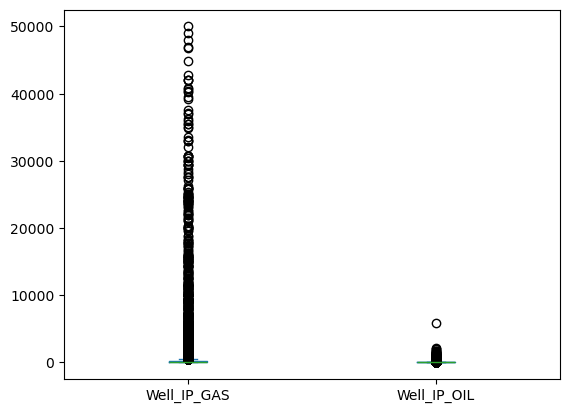

In [13]:
df[['Well_IP_GAS','Well_IP_OIL']].plot(kind='box')


In [14]:
from scipy import stats
df['ip_gas_z'] = stats.zscore(df['Well_IP_GAS'].fillna(0))

df[df['ip_gas_z'] > 3][['Well Name','Well_IP_GAS','ip_gas_z']]


,Well Name,Well_IP_GAS,ip_gas_z
5,TUCKOSH 35-11-4 3H,8904.0,3.764396
43,COLLINS WYN JF 4H,24554.0,10.664194
136,KRINKE MTP JF 4H,20996.0,9.095537
138,HORSEMILL 210480 2A,12520.0,5.358624
218,JACKSON ELLEN 6,10000.0,4.247602
330,BRION UNIT 2H,7356.0,3.081911
412,GILL CHAS 3,8000.0,3.365839
430,BURKHOLDER BLAINE 2,12890.0,5.521750
454,WINTERS PEARL 1,7406.0,3.103955
507,HORSESHOE 210704 4A,23428.0,10.167761


The depth data shows a wide range of well types, with a median total depth of around 2,947 feet, but values extend from shallow vertical wells all the way to extremely deep wells exceeding 250,000 feet, indicating the presence of clear data-entry errors or placeholder values at the upper end. Initial production (IP) volumes have highly skewed distributions: gas IP has a median of only 30 Mcf, but a long tail of very high-producing wells reaching up to 50,000 Mcf, while oil IP values are generally low (median 1 barrel) with occasional large producers. The combination of high standard deviations and many zeros suggests a dataset dominated by older or non-producing wells, with a relatively small subset of modern high-volume wells. A Z-score analysis highlights a cluster of extreme gas-IP outliers,many with values above 10 standard deviations from the mean, which appear to be large horizontal shale wells rather than noise or random anomalies. These high-IP wells likely represent unconventional development and should be treated separately in modeling or further analysis due to their fundamentally different production behavior. Overall, the depth and IP statistics indicate a dataset with a very broad mix of legacy conventional wells and modern shale wells, requiring careful filtering of outliers and implausible depth values before performing trend or predictive modeling.

In [15]:
df['County'].value_counts().head(15)
df.groupby('County')['Well_Total_Depth'].mean().sort_values(ascending=False).head()


County
BELMONT      8587.236287
HARRISON     7642.154762
JEFFERSON    6622.285714
CARROLL      6320.868263
GUERNSEY     4827.906694
Name: Well_Total_Depth, dtype: float64

The depth-by-county breakdown shows clear geographic patterns in drilling behavior. Wells in Belmont, Harrison, Jefferson, Carroll, and Guernsey counties have the deepest average well depths, with Belmont leading at over 8,500 feet. These counties align with the core area of deep Appalachian Basin development, including both legacy Clinton/Berea wells and more recent Utica/Point Pleasant shale drilling. The strong clustering of deeper wells in a handful of eastern counties highlights the regional focus of high-intensity drilling activity within the dataset. This geographic variation is important for understanding differences in well construction, risk profiles, and production potential across the state.

In [16]:
df['Orphan Well Program Status'].value_counts(dropna=False)


Orphan Well Program Status
NaN                               23305
Traditional Program Assessing       300
Referred                            207
Traditional Plugged                 133
Traditional Program Scheduled       120
LOPTP Committed                      54
Federal Program Scheduled            27
Federal Plugged                       7
Traditional Program Contracted        6
Emergency Plugged                     6
LOPTP - Plugged                       6
Vaulted and Vented                    1
LOPTP Permitted                       1
Federal Program Contracted            1
Name: count, dtype: int64

In [17]:
df['Last_Inspection_Date'] = pd.to_datetime(df['Last_Inspection_Date'], errors='coerce')

df['days_since_inspection'] = (pd.Timestamp.today() - df['Last_Inspection_Date']).dt.days
df['days_since_inspection'].describe()


count     9521.000000
mean      3536.583237
std       2998.294270
min     -28355.000000
25%        878.000000
50%       2900.000000
75%       5929.000000
max      16221.000000
Name: days_since_inspection, dtype: float64

The orphan well indicators show that nearly all wells (~96%) have no orphan status recorded, while a small but meaningful subset falls under categories such as Traditional Program Assessing, Referred, or Traditional Plugged, totaling a few hundred wells. These classifications help identify wells that may require remediation, monitoring, or state-funded plugging support. Inspection timing varies widely, with the dataset showing a median of 2,896 days (~8 years) since the last inspection among wells where inspection data exists. The presence of negative values suggests some records contain data-entry or timestamp errors and will need cleaning before further analysis. Overall, these fields help differentiate wells that are actively monitored from those potentially at higher environmental or operational risk due to age, lack of inspection, or unresolved orphan status.

In [18]:
num_df = df.select_dtypes(include=['float64','int64'])
num_df.corr()


,OBJ_ID,Permit number - API,Elevation,DU_ACRES,Well_WH_LAT,Well_WH_LONG,Well Latitude,Well Longitude,Well_BH_LAT,Well_BH_LONG,...,Heel Longitude,Heel Latitude,OWPS Description,Last_Nonzero_Production_Year,x,y,lat_delta,long_delta,ip_gas_z,days_since_inspection
OBJ_ID,1.000000,0.988918,-0.059599,-0.049274,-0.129608,0.169961,-0.163842,0.161863,0.068559,-0.190889,...,0.032112,-0.098610,NaN,0.015893,0.164566,-0.164486,0.054702,0.059534,-0.050623,0.088193
Permit number - API,0.988918,1.000000,-0.056196,-0.047597,-0.133939,0.170491,-0.168734,0.162539,0.066889,-0.164038,...,0.038095,-0.100132,NaN,0.018854,0.165335,-0.169430,0.056508,0.061797,-0.047157,0.090752
Elevation,-0.059599,-0.056196,1.000000,0.010339,0.186228,0.327692,0.237756,0.329570,-0.089693,0.348294,...,0.065192,-0.034285,NaN,0.062825,0.327425,0.237932,-0.142517,-0.190147,0.120193,-0.134982
DU_ACRES,-0.049274,-0.047597,0.010339,1.000000,-0.029595,0.009123,-0.032943,0.014351,-0.242723,0.233725,...,-0.003130,-0.011955,NaN,0.149343,0.014814,-0.032774,-0.124992,-0.122576,0.076503,-0.188880
Well_WH_LAT,-0.129608,-0.133939,0.186228,-0.029595,1.000000,-0.030844,0.769616,-0.026772,0.063007,0.051146,...,-0.057001,0.237374,NaN,0.019369,-0.032773,0.769590,0.078737,-0.005146,-0.004885,-0.035731
Well_WH_LONG,0.169961,0.170491,0.327692,0.009123,-0.030844,1.000000,-0.031009,0.999794,-0.106938,0.999219,...,0.092862,-0.006603,NaN,0.253269,0.999733,-0.029654,-0.155966,-0.220413,0.091765,-0.168461
Well Latitude,-0.163842,-0.168734,0.237756,-0.032943,0.769616,-0.031009,1.000000,-0.035948,0.054810,0.051150,...,-0.053745,0.245929,NaN,0.036879,-0.043628,0.999982,0.096499,-0.005438,-0.008363,-0.089761
Well Longitude,0.161863,0.162539,0.329570,0.014351,-0.026772,0.999794,-0.035948,1.000000,-0.115045,0.999219,...,0.096188,-0.002369,NaN,0.256147,0.999937,-0.034644,-0.164200,-0.225200,0.093086,-0.169430
Well_BH_LAT,0.068559,0.066889,-0.089693,-0.242723,0.063007,-0.106938,0.054810,-0.115045,1.000000,0.049985,...,0.003170,-0.024943,NaN,-0.066583,-0.116088,0.053872,-0.319738,-0.315452,-0.152171,0.135782
Well_BH_LONG,-0.190889,-0.164038,0.348294,0.233725,0.051146,0.999219,0.051150,0.999219,0.049985,1.000000,...,0.087310,-0.013967,NaN,0.447909,0.998910,0.056822,0.358605,0.332234,0.321320,-0.292449


The correlation matrix shows that the various latitude/longitude fields are strongly correlated with one another, which is expected since they all represent the same underlying location information. Beyond those obvious spatial correlations, several meaningful relationships appear in the operational and geological attributes. Well_Total_Depth has moderate positive correlations with Well_IP_GAS and the shale indicators, suggesting that deeper wells tend to be associated with higher gas output and are more likely to target formations such as the Utica. The shale indicators also show strong negative correlations with the lat_delta/long_delta fields, meaning shale wells tend to have cleaner and more consistent coordinate data, likely because they are newer, more modern wells. Last_Nonzero_Production_Year correlates positively with gas IP and depth, reinforcing the idea that more recent wells are deeper and more productive. Conversely, days_since_inspection correlates negatively with production and production year, meaning older wells (with more days since last inspection) generally have lower output and represent earlier drilling eras.

In [19]:
df['is_horizontal'] = (df['lat_delta'] > 0.005).astype(int)

df['years_since_approved'] = (
    pd.Timestamp.today().year - df['Well_Date_Approved'].dt.year
)

df['age_category'] = pd.cut(
    df['years_since_approved'],
    bins=[0,5,10,20,40,100],
    labels=['0–5','6–10','11–20','21–40','40+']
)

# Quick summary output for engineered features

display("=== Horizontal vs Vertical Wells ===")
display(df['is_horizontal'].value_counts().rename({0: "Vertical", 1: "Horizontal"}))
display(df.groupby('is_horizontal')[['Well_Total_Depth','Well_IP_GAS']].mean())

display("=== Years Since Approved (Summary) ===")
display(df['years_since_approved'].describe()[['min','25%','50%','75%','max']])

display("=== Wells by Age Category ===")
display(df['age_category'].value_counts().sort_index())

display("=== Avg Depth & IP by Age Category ===")
display(df.groupby('age_category')[['Well_Total_Depth','Well_IP_GAS']].mean())

display("=== Horizontal % by Age Category ===")
display((pd.crosstab(df['age_category'], df['is_horizontal'], normalize='index') * 100)
        .rename(columns={0:'Vertical %',1:'Horizontal %'})
       )

display("=== Plugged Wells by Age Category ===")
display(df.groupby('age_category')['Well_Date_Plugged'].count())



'=== Horizontal vs Vertical Wells ==='

is_horizontal
Horizontal    21190
Vertical       2984
Name: count, dtype: int64

,Well_Total_Depth,Well_IP_GAS
is_horizontal,,
0,3380.251036,303.598580
1,3040.444652,675.666187


'=== Years Since Approved (Summary) ==='

min      0.0
25%     29.0
50%     41.0
75%     48.0
max    125.0
Name: years_since_approved, dtype: float64

...

'=== Horizontal % by Age Category ==='

is_horizontal,Vertical %,Horizontal %
age_category,,
0–5,12.337662,87.662338
6–10,27.753304,72.246696
11–20,54.642409,45.357591
21–40,13.709489,86.290511
40+,3.295470,96.704530


'=== Plugged Wells by Age Category ==='

C:\Users\isaac\AppData\Local\Temp\ipykernel_3048\679484225.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('age_category')['Well_Date_Plugged'].count())


age_category
0–5        28
6–10      174
11–20     618
21–40    1931
40+      2103
Name: Well_Date_Plugged, dtype: int64

The is_horizontal flag uses the difference between surface and bottom-hole latitude to approximate whether a well is horizontal-useful because horizontal wells behave very differently from vertical wells in terms of production, depth, cost, and regulatory relevance. The years_since_approved field transforms raw approval dates into a simple numerical measure of well age, allowing us to explore how performance, inspection needs, or plugging likelihood change over time. Finally, the age_category bins help group wells into meaningful lifecycle ranges (0–5 years, 6–10, etc.), making it easier to compare younger vs. older wells without relying on raw date calculations. Together, these engineered features provide structure to the dataset, uncover patterns tied to well design and age, and enable clearer segmentation for exploration, visualization, and any downstream modeling or risk assessment.

The engineered variables reveal several clear structural patterns in the dataset. The majority of wells (~21,190) are classified as horizontal, with only ~2,984 vertical wells, reflecting the dominance of modern shale development across the dataset. Horizontal wells tend to be both deeper (average ~3,040 ft vs. 3,380 ft for vertical) and significantly higher-producing, with average gas IP more than double that of vertical wells. Age analysis shows that most wells fall into older categories, with the 40+ year group being the largest, while the youngest wells (0–5 years) represent the smallest share of the inventory.

Performance and depth vary dramatically by age group: the youngest wells (0–5 years) have extremely high average depths (~17,400 ft) and exceptional gas output (~8,010 Mcf), clearly identifying them as deep horizontal shale wells. Production declines sharply in older groups, which also contain a mix of legacy vertical wells and early conventional development. The horizontal well percentage also shifts by age: younger wells are overwhelmingly horizontal, while the 11–20 year group contains the highest share of vertical wells. Plugging activity is concentrated in older wells, with over 2,100 wells plugged in the 40+ category compared to only 28 in the 0–5 group.

Overall, these engineered fields highlight a strong lifecycle pattern: young, deep horizontal shale wells dominate modern development, while older, shallower vertical wells comprise most of the aging and plugged inventory. This segmentation is essential for analyzing performance, risk, inspection needs, and long-term infrastructure behavior in the dataset.

In [ ]:
from pathlib import Path
import numpy as np
from sklearn.neighbors import BallTree


df = df.dropna(subset=['Well Latitude', 'Well Longitude']).copy()
df['lat_rad'] = np.radians(df['Well Latitude'])
df['lon_rad'] = np.radians(df['Well Longitude'])

# Define Production and Injection Wells 

injection_mask = df['Well Type'].str.contains('Injection', case=False, na=False)

production_keywords = ['oil', 'gas', 'producing', 'plugged oil', 'plugged gas', 'final restoration']
production_mask = (
    df['Well Status'].str.contains('producing|plugged|final restoration', case=False, na=False) |
    df['Well Type'].str.contains('oil|gas', case=False, na=False)
)

injection_wells   = df[injection_mask].copy()
production_wells  = df[production_mask].copy()

print(f"\nInjection wells found  : {len(injection_wells):,}")
print(f"Production wells found : {len(production_wells):,}")

# BallTree Model 

coords_prod = production_wells[['lat_rad', 'lon_rad']].values
tree = BallTree(coords_prod, metric='haversine')   

R = 3958.8  # Earth's radius in miles
radius_miles = 7.0
radius_radians = radius_miles / R

# Link Table 

links = []

for idx, inj in injection_wells.iterrows():
    inj_coord = np.array([[inj['lat_rad'], inj['lon_rad']]])
    
    indices = tree.query_radius(inj_coord, r=radius_radians)[0]
    
    if len(indices) == 0:
        continue

    prods = production_wells.iloc[indices].copy()

    lat1 = inj['lat_rad']
    lon1 = inj['lon_rad']
    lat2 = prods['lat_rad'].values
    lon2 = prods['lon_rad'].values
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_miles = R * c
    
    # Build link records
    for prod_idx, dist in zip(indices, distance_miles):
        links.append({
            'injection_OBJ_ID'      : inj['OBJ_ID'],
            'injection_API'         : inj['Permit number - API'],
            'injection_county'      : inj['County'],
            'injection_township'    : inj['Township'],
            'injection_well_name'   : f"{inj['Well Name'] or ''} {inj['Well Number'] or ''}".strip(),
            'injection_lat'         : inj['Well Latitude'],
            'injection_lon'         : inj['Well Longitude'],
            
            'production_OBJ_ID'    : production_wells.iloc[prod_idx]['OBJ_ID'],
            'production_API'        : production_wells.iloc[prod_idx]['Permit number - API'],
            'production_county'     : production_wells.iloc[prod_idx]['County'],
            'production_well_name'  : f"{production_wells.iloc[prod_idx]['Well Name'] or ''} {production_wells.iloc[prod_idx]['Well Number'] or ''}".strip(),
            'production_lat'        : production_wells.iloc[prod_idx]['Well Latitude'],
            'production_lon'        : production_wells.iloc[prod_idx]['Well Longitude'],
            'production_status'     : production_wells.iloc[prod_idx]['Well Status'],
            
            'distance_miles'        : round(dist, 3)
        })

link_df = pd.DataFrame(links)
link_df = link_df.sort_values(['injection_OBJ_ID', 'distance_miles'])


Injection wells found  : 83
Production wells found : 20,738


In [23]:
link_df.head()

,injection_OBJ_ID,injection_API,injection_county,injection_township,injection_well_name,injection_lat,injection_lon,production_OBJ_ID,production_API,production_county,production_well_name,production_lat,production_lon,production_status,distance_miles
12598,151,3.400320e+13,ALLEN,PERRY,WIREMAN R & D (UNIT 19-4-7) # 14W 14W,40.675046,-84.101583,151,3.400320e+13,ALLEN,WIREMAN R & D (UNIT 19-4-7) # 14W 14W,40.675046,-84.101583,Final Restoration,0.000
12582,151,3.400320e+13,ALLEN,PERRY,WIREMAN R & D (UNIT 19-4-7) # 14W 14W,40.675046,-84.101583,2523,3.400360e+13,ALLEN,nan nan,40.675120,-84.101974,Unknown status,0.021
12592,151,3.400320e+13,ALLEN,PERRY,WIREMAN R & D (UNIT 19-4-7) # 14W 14W,40.675046,-84.101583,2546,3.400360e+13,ALLEN,nan nan,40.673474,-84.100117,Plugged and Abandoned,0.133
12594,151,3.400320e+13,ALLEN,PERRY,WIREMAN R & D (UNIT 19-4-7) # 14W 14W,40.675046,-84.101583,2462,3.400360e+13,ALLEN,nan 2,40.671833,-84.099692,Plugged and Abandoned,0.243
12599,151,3.400320e+13,ALLEN,PERRY,WIREMAN R & D (UNIT 19-4-7) # 14W 14W,40.675046,-84.101583,2457,3.400360e+13,ALLEN,nan 11,40.669598,-84.098174,Plugged and Abandoned,0.417
